# Introduction to Medical Imaging with Deep Learning

Welcome to this introductory course on Convolutional Neural Networks (CNNs) for medical imaging!
In this notebook, we will:
1. Download and load the **Chest X-Ray Images (Pneumonia)** dataset.
2. Perform a comprehensive Exploratory Data Analysis (EDA).
3. Train a custom CNN with Grid Search on validation data.
4. Monitor validation loss, checkpoint the best model, and plot training curves.
5. Evaluate on the test set, plot the ROC curve, and find the optimal threshold using **Namdar's B point**.
6. Display the confusion matrix and comprehensive metrics (Accuracy, F1, Sensitivity, Specificity).

In [1]:
# Install necessary packages (colab usually has most, but we ensure to explicitly install kagglehub and others)
!pip install -q -U kagglehub matplotlib seaborn scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 5.1 MB/s eta 0:00:00


In [2]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Download and Load Data
We use the dataset `paultimothymooney/chest-xray-pneumonia`.

In [3]:
print('Downloading dataset...')
dataset_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')
print(f'Dataset downloaded to: {dataset_path}')

data_dir = os.path.join(dataset_path, 'chest_xray')
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')
val_dir = os.path.join(data_dir, 'val')

# Note: The original 'val' set has very few images (16), so we will create our own validation set
# by splitting the train set later.

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset downloaded to: /kaggle/input/chest-xray-pneumonia


## 2. Comprehensive EDA
Let's analyze the dataset distributions and sample images.

Total Training images: 5216
Total Testing images: 624


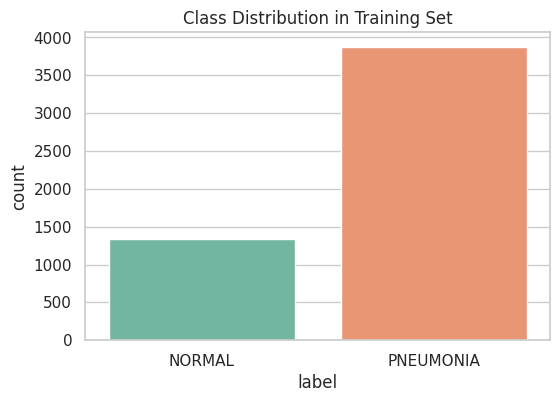

Notice the class imbalance. This is typical in medical datasets.


In [4]:
def get_dataframe(folder_path):
    data = []
    classes = ['NORMAL', 'PNEUMONIA']
    for label in classes:
        class_dir = os.path.join(folder_path, label)
        if not os.path.exists(class_dir): continue
        for img_name in os.listdir(class_dir):
            if img_name.endswith(('.jpeg', '.jpg', '.png')):
                data.append({
                    'image_path': os.path.join(class_dir, img_name),
                    'label': label,
                    'class_idx': 0 if label == 'NORMAL' else 1
                })
    return pd.DataFrame(data)

df_train = get_dataframe(train_dir)
df_test = get_dataframe(test_dir)

print(f"Total Training images: {len(df_train)}")
print(f"Total Testing images: {len(df_test)}")

# Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df_train, x='label', palette='Set2')
plt.title('Class Distribution in Training Set')
plt.show()

print("Notice the class imbalance. This is typical in medical datasets.")

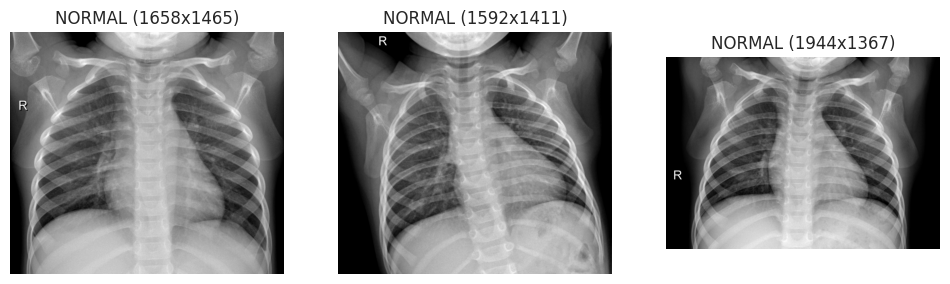

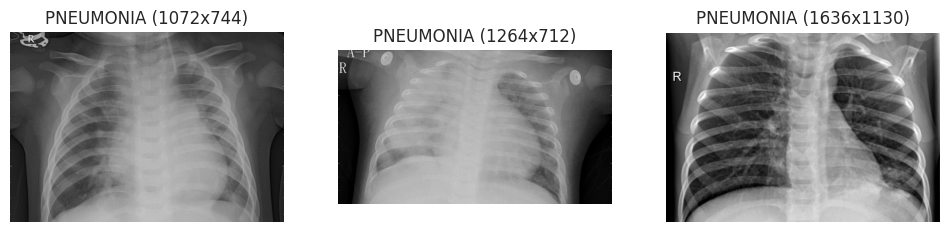

In [5]:
# Visualize Samples
def plot_samples(df, label, n=3):
    samples = df[df['label'] == label].sample(n, random_state=42)
    plt.figure(figsize=(12, 4))
    for i, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row['image_path'])
        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"{label} ({img.size[0]}x{img.size[1]})")
        plt.axis('off')
    plt.show()

plot_samples(df_train, 'NORMAL', 3)
plot_samples(df_train, 'PNEUMONIA', 3)

## 3. Data Loaders & Model Architecture
We will set up our `DataLoader`s and define our Custom CNN architecture.

In [6]:
IMG_SIZE = 128

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

# Split train to train & val (80/20) for grid search and monitoring
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print(f"Training instances: {len(train_dataset)}")
print(f"Validation instances: {len(val_dataset)}")

Training instances: 4172
Validation instances: 1044


In [7]:
# Simple Custom CNN
class CustomCNN(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.dropout = nn.Dropout(dropout_rate)
        # We use a single output node for binary classification with BCEWithLogitsLoss
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## 4. Training with Minimal Grid Search & Checkpointing
We perform a grid search over a few hyperparameter combinations, monitor validation loss, checkpoint the best model, and plot the training and validation loss curves.

Starting Grid Search...

--- Testing LR: 0.001, Dropout: 0.3 ---
Epoch 1/5 | Train Loss: 0.1829 | Val Loss: 0.1032
Epoch 2/5 | Train Loss: 0.0923 | Val Loss: 0.0565
Epoch 3/5 | Train Loss: 0.0800 | Val Loss: 0.0546
Epoch 4/5 | Train Loss: 0.0692 | Val Loss: 0.0493
Epoch 5/5 | Train Loss: 0.0662 | Val Loss: 0.0456

--- Testing LR: 0.001, Dropout: 0.5 ---
Epoch 1/5 | Train Loss: 0.1651 | Val Loss: 0.0704
Epoch 2/5 | Train Loss: 0.0900 | Val Loss: 0.0600
Epoch 3/5 | Train Loss: 0.0839 | Val Loss: 0.0530
Epoch 4/5 | Train Loss: 0.0727 | Val Loss: 0.0455
Epoch 5/5 | Train Loss: 0.0678 | Val Loss: 0.0473

--- Testing LR: 0.0005, Dropout: 0.3 ---
Epoch 1/5 | Train Loss: 0.1898 | Val Loss: 0.1305
Epoch 2/5 | Train Loss: 0.0972 | Val Loss: 0.0650
Epoch 3/5 | Train Loss: 0.0774 | Val Loss: 0.0849
Epoch 4/5 | Train Loss: 0.0816 | Val Loss: 0.0644
Epoch 5/5 | Train Loss: 0.0700 | Val Loss: 0.0514

--- Testing LR: 0.0005, Dropout: 0.5 ---
Epoch 1/5 | Train Loss: 0.2146 | Val Loss: 0.0972
Epoch 2/5 

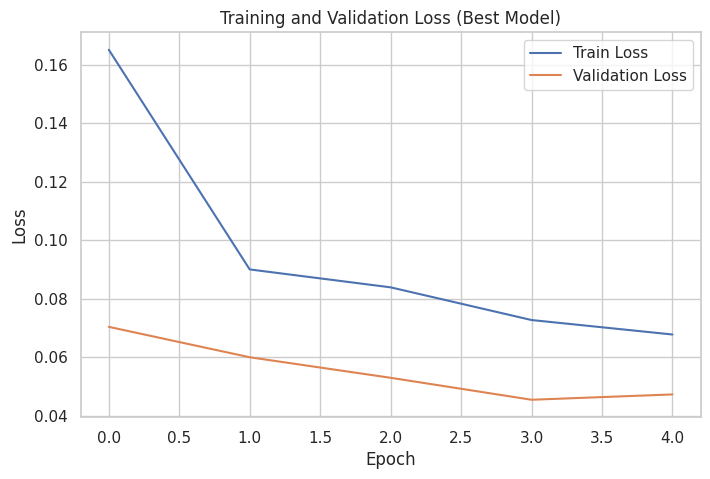

In [8]:
import copy
from tqdm.notebook import tqdm

def train_model(model, train_loader, val_loader, learning_rate, epochs=5):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    # Roughly Normal: 1341, Pneumonia: 3875
    pos_weight = torch.tensor([1341.0 / 3875.0]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.float().unsqueeze(1).to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.float().unsqueeze(1).to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    model.load_state_dict(best_model_wts)
    return model, train_losses, val_losses, best_val_loss

learning_rates = [1e-3, 5e-4]
dropout_rates = [0.3, 0.5]
BATCH_SIZE = 64
EPOCHS = 5

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

best_overall_val_loss = float('inf')
best_overall_model = None
best_history = None
best_params = {}

print("Starting Grid Search...")
for lr in learning_rates:
    for drop in dropout_rates:
        print(f"\n--- Testing LR: {lr}, Dropout: {drop} ---")
        model = CustomCNN(dropout_rate=drop).to(device)
        trained_model, t_losses, v_losses, best_v_loss = train_model(model, train_loader, val_loader, lr, EPOCHS)

        if best_v_loss < best_overall_val_loss:
            best_overall_val_loss = best_v_loss
            best_overall_model = trained_model
            best_history = (t_losses, v_losses)
            best_params = {'LR': lr, 'Dropout': drop}

print(f"\nBest Parameters found: {best_params} with Val Loss: {best_overall_val_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(best_history[0], label='Train Loss')
plt.plot(best_history[1], label='Validation Loss')
plt.title('Training and Validation Loss (Best Model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

torch.save(best_overall_model.state_dict(), 'best_model.pth')

## 5. ROC Curve & Namdar's B Point Threshold
We evaluate the loaded model on the test set, plot the ROC curve, and apply **Namdar's B point** to find the optimal threshold for classifying normal vs. pneumonia cases.

*Note: Namdar's B Point defines a new threshold determination method along the ROC curve to balance the weights of the classes and find an optimal operating point. It identifies the juncture where weights are balanced.*

Namdar's B Point Optimal Threshold: 0.9791


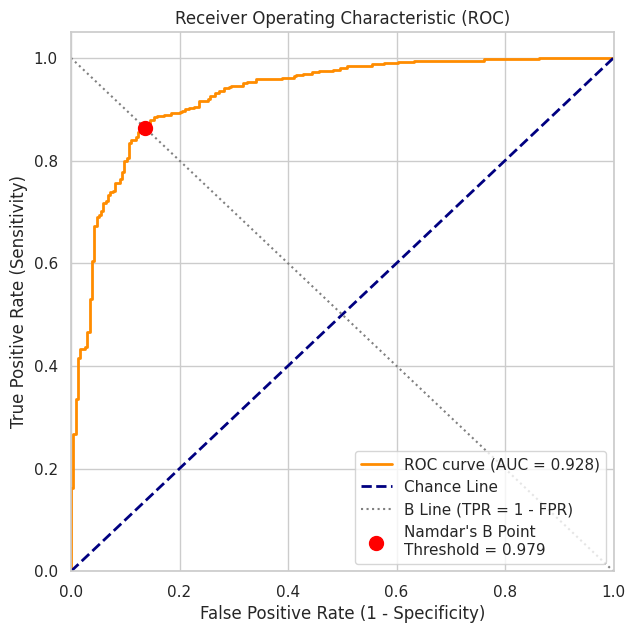

In [9]:
best_overall_model.load_state_dict(torch.load('best_model.pth', weights_only=True))
best_overall_model.eval()

y_true = []
y_scores = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = best_overall_model(inputs)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        y_scores.extend(probs)
        y_true.extend(labels.numpy())

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Calculate Namdar's B Point
# A commonly used approximation for Namdar's B point is the intersection
# of the ROC with TPR = 1 - FPR (which is equivalent to finding the break-even
# point where Sensitivity = Specificity).
distances_to_b_line = np.abs(tpr + fpr - 1)
namdar_b_idx = np.argmin(distances_to_b_line)

namdar_b_threshold = thresholds[namdar_b_idx]
optimal_fpr = fpr[namdar_b_idx]
optimal_tpr = tpr[namdar_b_idx]

print(f"Namdar's B Point Optimal Threshold: {namdar_b_threshold:.4f}")

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance Line')

b_line_x = np.linspace(0, 1, 100)
b_line_y = 1 - b_line_x
plt.plot(b_line_x, b_line_y, color='gray', linestyle=':', label='B Line (TPR = 1 - FPR)')

plt.scatter(optimal_fpr, optimal_tpr, color='red', s=100, zorder=5, label=f"Namdar's B Point\nThreshold = {namdar_b_threshold:.3f}")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

## 6. Comprehensive Metrics Evaluation
Applying Namdar's B Point threshold, we generate the final predictions, confusion matrix, and reporting metrics.

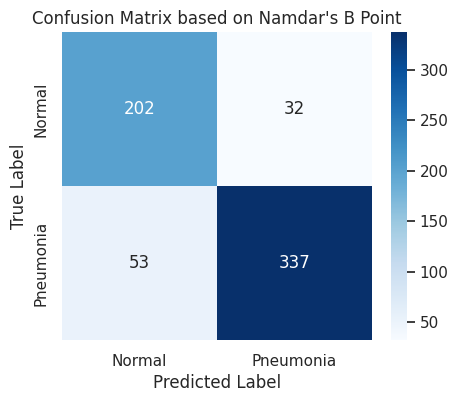


=== Comprehensive Metrics ===
Accuracy:    0.8638
F1 Score:    0.8880
Sensitivity: 0.8641 (True Positive Rate)
Specificity: 0.8632 (True Negative Rate)

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.79      0.86      0.83       234
   Pneumonia       0.91      0.86      0.89       390

    accuracy                           0.86       624
   macro avg       0.85      0.86      0.86       624
weighted avg       0.87      0.86      0.86       624



In [10]:
y_pred = (np.array(y_scores) >= namdar_b_threshold).astype(int)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title("Confusion Matrix based on Namdar's B Point")
plt.show()

tn, fp, fn, tp = cm.ravel()
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("\n=== Comprehensive Metrics ===")
print(f"Accuracy:    {accuracy:.4f}")
print(f"F1 Score:    {f1:.4f}")
print(f"Sensitivity: {sensitivity:.4f} (True Positive Rate)")
print(f"Specificity: {specificity:.4f} (True Negative Rate)")

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))